
# Chương 8 – Hidden Markov Models (HMM)
## Học lý thuyết + thực hành trực tiếp với `demo_overlap.wav`

Notebook này bám theo cấu trúc Chương 8 của *Spoken Language Processing*:

- **8.1. The Markov Chain**
- **8.2. Definition of the Hidden Markov Model**
  - 8.2.1. Dynamic Programming and DTW
  - 8.2.2. Forward Algorithm
  - 8.2.3. Viterbi Algorithm
  - 8.2.4. Baum–Welch / Forward–Backward
- **8.3. Continuous and Semi-continuous HMMs**
- **8.4. Practical Issues in Using HMMs**
- **8.5. HMM Limitations**

### Mục tiêu

1. Hiểu HMM từ Markov chain.
2. Biến audio thành chuỗi observation.
3. Tự cài **Forward, Viterbi, Baum–Welch** bằng NumPy.
4. Train một **discrete HMM** trên chính file audio.
5. Mở rộng sang **continuous Gaussian HMM**.
6. Hiểu topology, smoothing, underflow và các giới hạn của HMM.

> **Lưu ý:** hidden states học được từ một file audio không tự động tương ứng với phoneme. Chúng chỉ là các trạng thái ẩn mà mô hình dùng để giải thích cấu trúc thống kê của tín hiệu.


In [2]:
# from google.colab import drive
# drive.mount('/content/drive')
print("Đã bỏ qua mount Drive vì file demo_overlap.wav đã có sẵn trong Colab!")

Đã bỏ qua mount Drive vì file demo_overlap.wav đã có sẵn trong Colab!


# 0. Bản đồ kiến thức Chương 8

Một HMM thường được ký hiệu:

$$\Phi=(A,B,\pi)$$

Trong đó:

- $A$: ma trận xác suất chuyển trạng thái.
- $B$: xác suất / mật độ phát xạ observation.
- $\pi$: phân phối trạng thái ban đầu.

Ba bài toán trung tâm:

| Bài toán | Câu hỏi | Thuật toán |
|---|---|---|
| Evaluation | $P(X\mid\Phi)$ bằng bao nhiêu? | Forward |
| Decoding | Chuỗi state ẩn tốt nhất là gì? | Viterbi |
| Learning | Học $A,B,\pi$ từ dữ liệu thế nào? | Baum–Welch |

Toàn bộ notebook sẽ quay lại ba câu hỏi này nhiều lần.

In [3]:

from pathlib import Path
import wave
import numpy as np
import matplotlib.pyplot as plt

from scipy import signal
from scipy.fftpack import dct
from sklearn.cluster import KMeans

np.set_printoptions(precision=4, suppress=True)

def find_audio():
    candidates = [
        Path("demo_overlap.wav"),
        Path("/mnt/data/demo_overlap.wav"),
        Path("/content/demo_overlap.wav"),
    ]
    for p in candidates:
        if p.exists():
            return p
    raise FileNotFoundError(
        "Không tìm thấy demo_overlap.wav. "
        "Hãy đặt file cùng thư mục notebook hoặc sửa AUDIO_PATH."
    )

AUDIO_PATH = find_audio()
print("Audio path:", AUDIO_PATH)


Audio path: demo_overlap.wav



# 1. Đọc audio và quan sát waveform

HMM không làm việc trực tiếp với toàn bộ waveform như một vector duy nhất.  
Ta cần biến tín hiệu thành một **chuỗi frame theo thời gian**.

Trước hết, ta đọc audio và kiểm tra:

- sample rate,
- số kênh,
- số mẫu,
- thời lượng.


In [4]:

with wave.open(str(AUDIO_PATH), "rb") as wf:
    n_channels = wf.getnchannels()
    sample_rate = wf.getframerate()
    n_frames = wf.getnframes()
    sample_width = wf.getsampwidth()
    raw = wf.readframes(n_frames)

dtype_map = {1: np.uint8, 2: np.int16, 4: np.int32}
dtype = dtype_map[sample_width]
x = np.frombuffer(raw, dtype=dtype)

if sample_width == 1:
    x = (x.astype(np.float64) - 128.0) / 128.0
else:
    x = x.astype(np.float64) / float(2 ** (8 * sample_width - 1))

if n_channels > 1:
    x = x.reshape(-1, n_channels).mean(axis=1)

duration = len(x) / sample_rate

print(f"Sample rate : {sample_rate} Hz")
print(f"Channels    : {n_channels}")
print(f"Sample width: {sample_width} bytes")
print(f"Samples     : {len(x):,}")
print(f"Duration    : {duration:.3f} s")


Sample rate : 16000 Hz
Channels    : 1
Sample width: 2 bytes
Samples     : 1,337,309
Duration    : 83.582 s


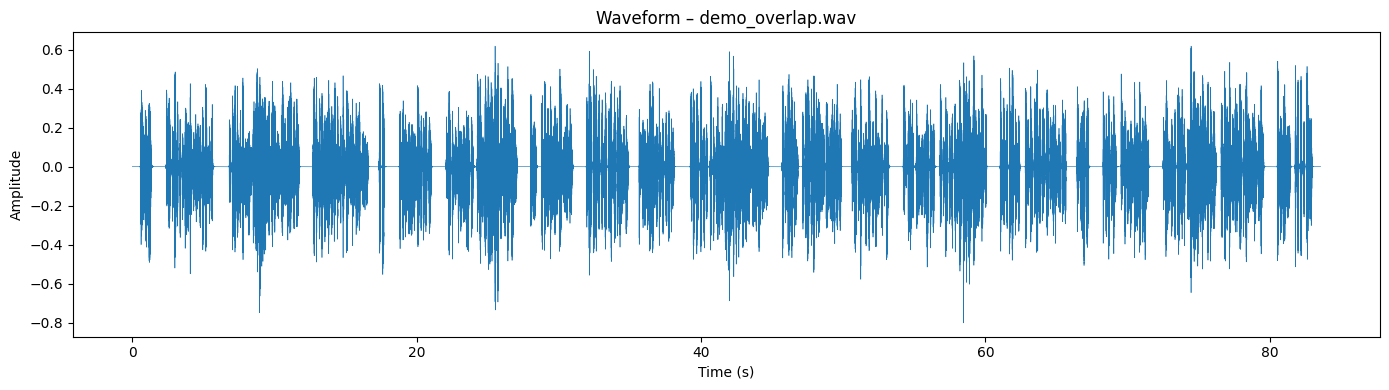

In [5]:

t = np.arange(len(x)) / sample_rate

plt.figure(figsize=(14, 4))
plt.plot(t, x, linewidth=0.45)
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.title("Waveform – demo_overlap.wav")
plt.tight_layout()
plt.show()


## Ý nghĩa của waveform

Waveform cho ta biên độ theo thời gian, nhưng nó **chưa phải observation phù hợp cho HMM**.

Speech chỉ gần như ổn định trong các đoạn rất ngắn. Vì vậy ta thường:

1. chia audio thành frame ngắn,
2. lấy đặc trưng cho từng frame,
3. coi các vector đặc trưng đó là chuỗi:

$$X=(x_1,x_2,\ldots,x_T)$$

Đây chính là observation sequence mà HMM sẽ mô hình hóa.

# 2. Chia frame và Spectrogram

Ta dùng:

- frame length: **25 ms**
- hop: **10 ms**
- window: Hamming
- FFT size: 512

Spectrogram giúp nhìn năng lượng theo:

$$\text{time} \times \text{frequency}$$


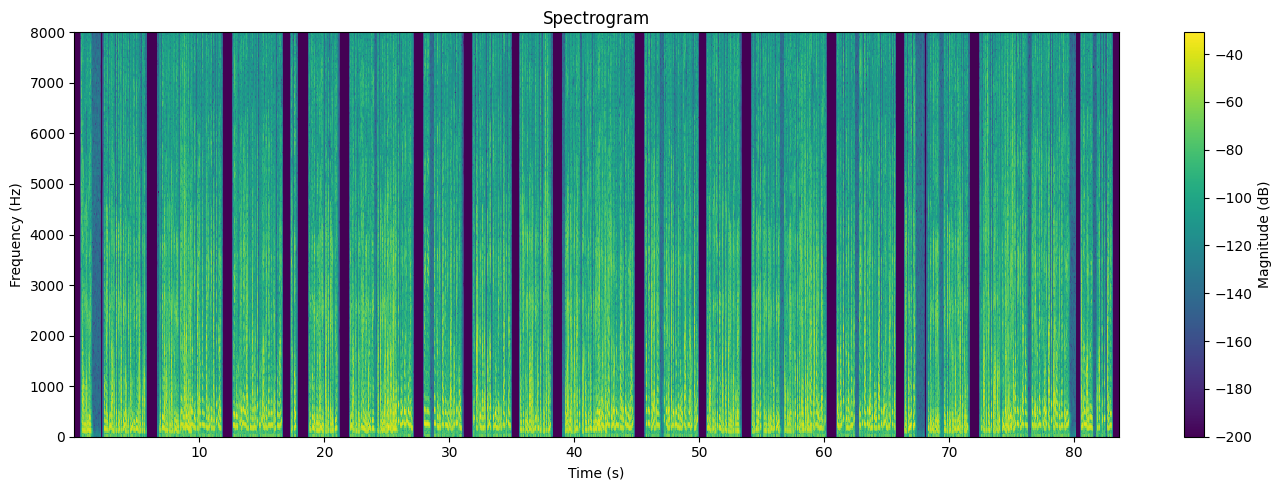

In [6]:

FRAME_MS = 25
HOP_MS = 10
NFFT = 512

frame_len = round(FRAME_MS * 1e-3 * sample_rate)
frame_step = round(HOP_MS * 1e-3 * sample_rate)
noverlap = frame_len - frame_step

freqs, times_spec, S = signal.spectrogram(
    x,
    fs=sample_rate,
    window="hamming",
    nperseg=frame_len,
    noverlap=noverlap,
    nfft=NFFT,
    mode="magnitude",
)

S_db = 20 * np.log10(S + 1e-10)

plt.figure(figsize=(14, 5))
plt.pcolormesh(times_spec, freqs, S_db, shading="auto")
plt.ylim(0, sample_rate / 2)
plt.xlabel("Time (s)")
plt.ylabel("Frequency (Hz)")
plt.title("Spectrogram")
plt.colorbar(label="Magnitude (dB)")
plt.tight_layout()
plt.show()


# 3. Trích MFCC – tạo observation vectors

Pipeline:

$$\text{audio} \rightarrow \text{pre-emphasis} \rightarrow \text{framing} \rightarrow \text{window} \rightarrow \text{FFT} \rightarrow \text{Mel filterbank} \rightarrow \log \rightarrow \text{DCT} \rightarrow \text{MFCC}$$

Ta lấy **13 hệ số MFCC** cho mỗi frame.

Khi đó:

$$x_t \in \mathbb{R}^{13}$$

và toàn bộ audio trở thành:

$$X=(x_1,\ldots,x_T)$$

In [7]:

pre_emphasis = 0.97
x_pre = np.append(x[0], x[1:] - pre_emphasis * x[:-1])

num_frames = 1 + int(np.ceil((len(x_pre) - frame_len) / frame_step))
pad_len = (num_frames - 1) * frame_step + frame_len
x_pad = np.append(x_pre, np.zeros(max(0, pad_len - len(x_pre))))

indices = (
    np.tile(np.arange(frame_len), (num_frames, 1))
    + np.tile(np.arange(num_frames) * frame_step, (frame_len, 1)).T
)

frames = x_pad[indices]
frames *= np.hamming(frame_len)

mag = np.abs(np.fft.rfft(frames, NFFT))
power = (1.0 / NFFT) * mag**2

def hz_to_mel(hz):
    return 2595.0 * np.log10(1.0 + hz / 700.0)

def mel_to_hz(mel):
    return 700.0 * (10 ** (mel / 2595.0) - 1.0)

N_FILTERS = 26
mel_points = np.linspace(
    hz_to_mel(0),
    hz_to_mel(sample_rate / 2),
    N_FILTERS + 2,
)
hz_points = mel_to_hz(mel_points)
bins = np.floor((NFFT + 1) * hz_points / sample_rate).astype(int)

fbank = np.zeros((N_FILTERS, NFFT // 2 + 1))

for m in range(1, N_FILTERS + 1):
    left, center, right = bins[m-1], bins[m], bins[m+1]
    center = max(center, left + 1)
    right = max(right, center + 1)

    for k in range(left, min(center, fbank.shape[1])):
        fbank[m-1, k] = (k - left) / (center - left)

    for k in range(center, min(right, fbank.shape[1])):
        fbank[m-1, k] = (right - k) / (right - center)

filter_energy = np.maximum(power @ fbank.T, 1e-12)
log_fbanks = np.log(filter_energy)

mfcc = dct(log_fbanks, type=2, axis=1, norm="ortho")[:, :13]

mfcc_mean = mfcc.mean(axis=0, keepdims=True)
mfcc_std = mfcc.std(axis=0, keepdims=True) + 1e-8
mfcc_norm = (mfcc - mfcc_mean) / mfcc_std

frame_times = np.arange(num_frames) * frame_step / sample_rate

print("MFCC shape:", mfcc.shape)
print("Số frame:", num_frames)
print("Mỗi frame có", mfcc.shape[1], "hệ số MFCC")


MFCC shape: (8357, 13)
Số frame: 8357
Mỗi frame có 13 hệ số MFCC


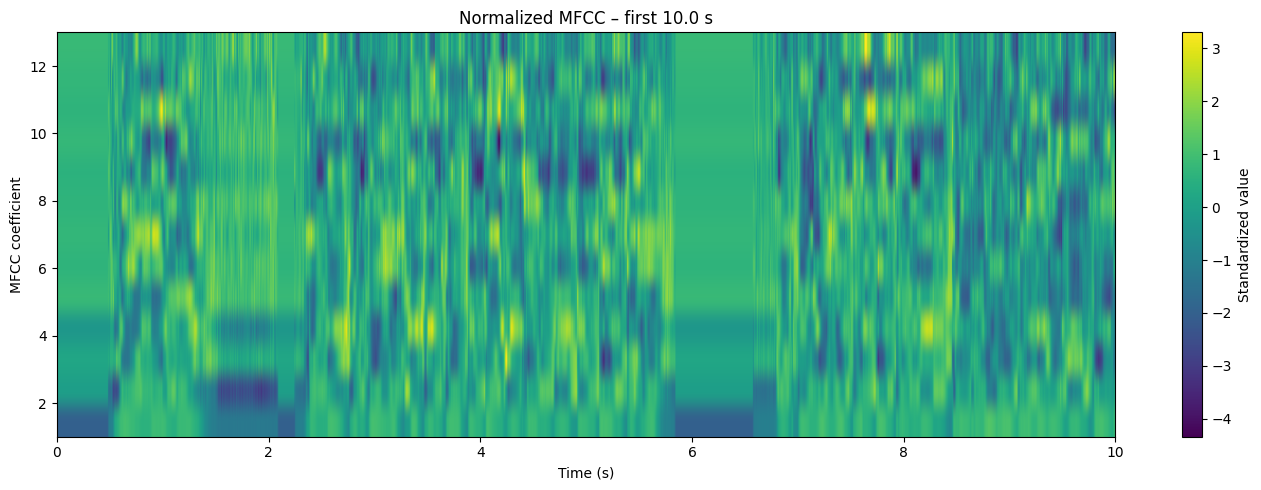

In [8]:

view_sec = min(10.0, duration)
view_n = min(len(mfcc_norm), int(view_sec / (frame_step / sample_rate)))

plt.figure(figsize=(14, 5))
plt.imshow(
    mfcc_norm[:view_n].T,
    aspect="auto",
    origin="lower",
    extent=[0, view_sec, 1, 13],
)
plt.xlabel("Time (s)")
plt.ylabel("MFCC coefficient")
plt.title(f"Normalized MFCC – first {view_sec:.1f} s")
plt.colorbar(label="Standardized value")
plt.tight_layout()
plt.show()


# 4. 8.1 – The Markov Chain

Với Markov chain bậc 1:

$$P(s_t\mid s_1,\ldots,s_{t-1}) = P(s_t\mid s_{t-1})$$

Tức là state hiện tại chỉ phụ thuộc trực tiếp vào state ngay trước nó.

Với $N$ trạng thái:

$$a_{ij}=P(s_t=j\mid s_{t-1}=i)$$

Các $a_{ij}$ tạo thành transition matrix:

$$A=[a_{ij}]$$

với:

$$\sum_j a_{ij}=1$$

Phân phối ban đầu:

$$\pi_i=P(s_1=i)$$

In [9]:

A_toy = np.array([
    [0.7, 0.3],
    [0.4, 0.6],
])

pi_toy = np.array([0.8, 0.2])

# P(State1 -> State1 -> State2)
p_path = pi_toy[0] * A_toy[0, 0] * A_toy[0, 1]

print("P(S1 -> S1 -> S2) =", p_path)


P(S1 -> S1 -> S2) = 0.16799999999999998


# 5. 8.2 – Definition of the Hidden Markov Model

Khác Markov chain thông thường, HMM có **state ẩn**.

Ta không quan sát trực tiếp:

$$S=(s_1,s_2,\ldots,s_T)$$

mà chỉ quan sát:

$$X=(x_1,x_2,\ldots,x_T)$$

Một discrete HMM gồm:

$$\Phi=(A,B,\pi)$$

### Transition probability

$$a_{ij}=P(s_t=j\mid s_{t-1}=i)$$

### Emission probability

$$b_i(k)=P(X_t=o_k\mid s_t=i)$$

### Initial probability

$$\pi_i=P(s_1=i)$$

Hai giả định quan trọng:

### Markov assumption

$$P(s_t\mid s_1,\ldots,s_{t-1}) = P(s_t\mid s_{t-1})$$

### Output conditional independence

$$P(X_t\mid X_1,\ldots,X_{t-1},s_t) = P(X_t\mid s_t)$$

# 6. Biến MFCC liên tục thành discrete observations

Để học discrete HMM trước, ta dùng **Vector Quantization** bằng K-Means.

Mỗi frame:

$$x_t \in \mathbb{R}^{13}$$

được ánh xạ thành một symbol:

$$o_k,\quad k\in\{0,\ldots,M-1\}$$

Khi đó:

$$O=(o_1,o_2,\ldots,o_T)$$

Đây là cầu nối giữa audio thực tế và discrete HMM.

In [10]:

N_SYMBOLS = 8

kmeans = KMeans(
    n_clusters=N_SYMBOLS,
    random_state=42,
    n_init=10,
)

obs = kmeans.fit_predict(mfcc_norm)

print("Observation sequence shape:", obs.shape)
print("Các symbol:", np.unique(obs))
print("20 symbol đầu tiên:", obs[:20])


Observation sequence shape: (8357,)
Các symbol: [0 1 2 3 4 5 6 7]
20 symbol đầu tiên: [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


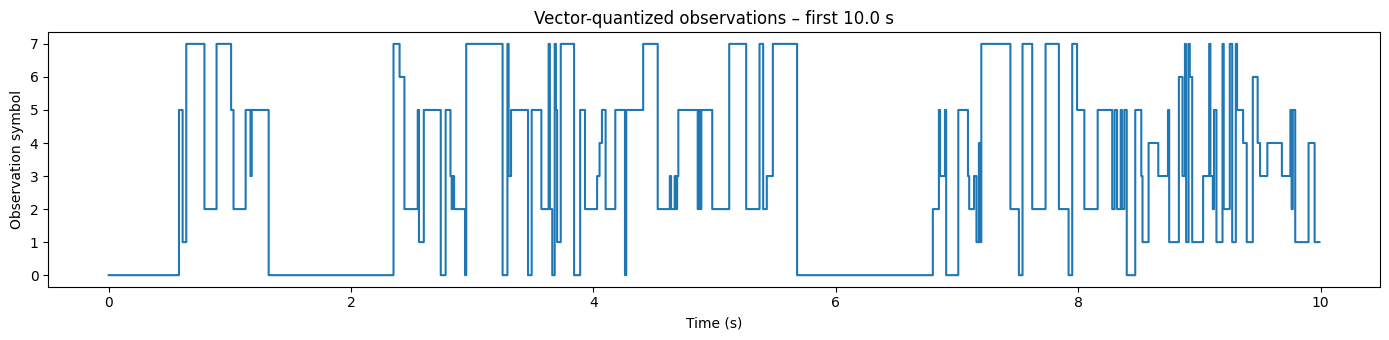

In [11]:

plt.figure(figsize=(14, 3.5))
plt.step(frame_times[:view_n], obs[:view_n], where="post")
plt.xlabel("Time (s)")
plt.ylabel("Observation symbol")
plt.title(f"Vector-quantized observations – first {view_sec:.1f} s")
plt.yticks(range(N_SYMBOLS))
plt.tight_layout()
plt.show()


# 7. 8.2.1 – Dynamic Programming và DTW

Nếu liệt kê tất cả path, số lượng path tăng theo hàm mũ.

Dynamic Programming dùng ý tưởng:

> Khi một sub-problem đã được giải, lưu kết quả lại để không phải tính lại.

Với DTW:

$$D(i,j)=d(i,j)+\min(\text{các predecessor hợp lệ})$$

Ý tưởng này xuất hiện lại trong:

- Forward: **sum** các path,
- Viterbi: **max** path,
- Baum–Welch: Forward + Backward để tính kỳ vọng.

DTW distance: 39.57805978384909


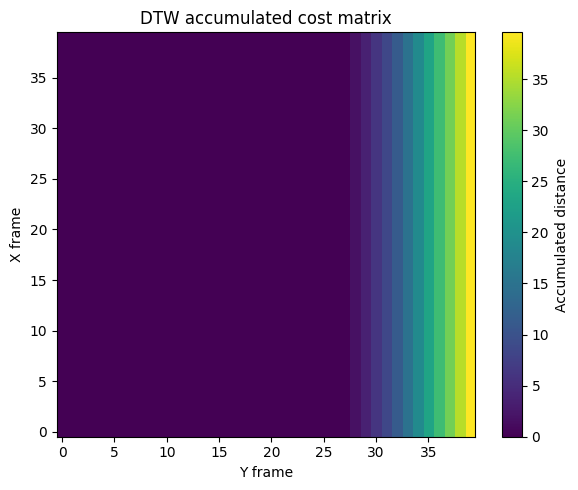

In [12]:

def dtw_distance(X, Y):
    n, m = len(X), len(Y)
    D = np.full((n + 1, m + 1), np.inf)
    D[0, 0] = 0.0

    for i in range(1, n + 1):
        for j in range(1, m + 1):
            cost = np.linalg.norm(X[i-1] - Y[j-1])
            D[i, j] = cost + min(
                D[i-1, j],
                D[i, j-1],
                D[i-1, j-1],
            )

    return D[n, m], D

X_demo = mfcc_norm[:40]
Y_demo = mfcc_norm[20:60]

dist_dtw, Dmat = dtw_distance(X_demo, Y_demo)
print("DTW distance:", dist_dtw)

plt.figure(figsize=(6, 5))
plt.imshow(Dmat[1:, 1:], origin="lower", aspect="auto")
plt.xlabel("Y frame")
plt.ylabel("X frame")
plt.title("DTW accumulated cost matrix")
plt.colorbar(label="Accumulated distance")
plt.tight_layout()
plt.show()


# 8. 8.2.2 – Forward Algorithm

## Bài toán Evaluation

Ta cần tính:

$$P(X\mid\Phi)$$

Forward định nghĩa:

$$\alpha_t(i) = P(X_1,\ldots,X_t,s_t=i\mid\Phi)$$

### Initialization

$$\alpha_1(i)=\pi_i b_i(X_1)$$

### Recursion

$$\alpha_t(j) = \left[ \sum_i \alpha_{t-1}(i)a_{ij} \right] b_j(X_t)$$

### Termination

$$P(X\mid\Phi)=\sum_i \alpha_T(i)$$

Trong code thực tế, ta dùng **scaling** để tránh underflow.

In [13]:

def normalize_rows(M, eps=1e-12):
    M = np.maximum(M, eps)
    return M / M.sum(axis=1, keepdims=True)

def forward_scaled(obs_seq, A, B, pi):
    T = len(obs_seq)
    N = len(pi)

    alpha = np.zeros((T, N), dtype=np.float64)
    scales = np.zeros(T, dtype=np.float64)

    alpha[0] = pi * B[:, obs_seq[0]]
    scales[0] = max(alpha[0].sum(), 1e-300)
    alpha[0] /= scales[0]

    for t in range(1, T):
        alpha[t] = (alpha[t-1] @ A) * B[:, obs_seq[t]]
        scales[t] = max(alpha[t].sum(), 1e-300)
        alpha[t] /= scales[t]

    log_likelihood = np.log(scales).sum()
    return alpha, scales, log_likelihood


# 9. 8.2.3 – Viterbi Algorithm

Forward cộng xác suất của **tất cả** path.

Viterbi tìm **một path tốt nhất**:

$$S^*=\arg\max_S P(S,X\mid\Phi)$$

Recursion:

$$\delta_t(j) = \max_i \left[ \delta_{t-1}(i)a_{ij} \right] b_j(X_t)$$

Khác biệt cốt lõi:

- Forward: `sum`
- Viterbi: `max`

Ta lưu backpointer:

$$\psi_t(j)$$

để backtrack state sequence.

In [14]:

def viterbi_decode(obs_seq, A, B, pi):
    eps = 1e-300

    logA = np.log(np.maximum(A, eps))
    logB = np.log(np.maximum(B, eps))
    logpi = np.log(np.maximum(pi, eps))

    T = len(obs_seq)
    N = len(pi)

    delta = np.zeros((T, N), dtype=np.float64)
    psi = np.zeros((T, N), dtype=int)

    delta[0] = logpi + logB[:, obs_seq[0]]

    for t in range(1, T):
        scores = delta[t-1][:, None] + logA
        psi[t] = np.argmax(scores, axis=0)
        delta[t] = np.max(scores, axis=0) + logB[:, obs_seq[t]]

    states = np.zeros(T, dtype=int)
    states[-1] = np.argmax(delta[-1])

    for t in range(T-2, -1, -1):
        states[t] = psi[t+1, states[t+1]]

    return states, delta, psi


# 10. 8.2.4 – Baum–Welch / Forward–Backward

## Bài toán Learning

Ta có observation nhưng không biết state sequence thật.

Mục tiêu:

$$\hat{\Phi} = \arg\max_{\Phi}P(X\mid\Phi)$$

Baum–Welch là một trường hợp của EM.

Ta cần:

### Forward probability

$$\alpha_t(i)$$

### Backward probability

$$\beta_t(i) = P(X_{t+1},\ldots,X_T\mid s_t=i,\Phi)$$

### State posterior

$$\gamma_t(i) = P(s_t=i\mid X,\Phi)$$

### Transition posterior

$$\xi_t(i,j) = P(s_t=i,s_{t+1}=j\mid X,\Phi)$$

Sau đó cập nhật $A,B,\pi$ từ các expected counts.

Baum–Welch làm likelihood không giảm sau mỗi iteration, nhưng thường chỉ hội tụ tới **local maximum**.

In [15]:

def backward_scaled(obs_seq, A, B, scales):
    T = len(obs_seq)
    N = A.shape[0]

    beta = np.zeros((T, N), dtype=np.float64)
    beta[-1] = 1.0

    for t in range(T-2, -1, -1):
        beta[t] = A @ (B[:, obs_seq[t+1]] * beta[t+1])
        beta[t] /= max(scales[t+1], 1e-300)

    return beta


def baum_welch_discrete(
    obs_seq,
    n_states=3,
    n_symbols=8,
    n_iter=20,
    seed=7,
):
    rng = np.random.default_rng(seed)

    A = normalize_rows(rng.random((n_states, n_states)) + 0.5)
    B = normalize_rows(rng.random((n_states, n_symbols)) + 0.5)

    pi = rng.random(n_states) + 0.5
    pi /= pi.sum()

    history = []

    for _ in range(n_iter):
        alpha, scales, ll = forward_scaled(obs_seq, A, B, pi)
        beta = backward_scaled(obs_seq, A, B, scales)
        history.append(ll)

        gamma = alpha * beta
        gamma /= np.maximum(
            gamma.sum(axis=1, keepdims=True),
            1e-300,
        )

        xi_sum = np.zeros_like(A)

        for t in range(len(obs_seq) - 1):
            numer = (
                alpha[t, :, None]
                * A
                * (B[:, obs_seq[t+1]] * beta[t+1])[None, :]
            )
            xi_sum += numer / max(numer.sum(), 1e-300)

        pi = gamma[0].copy()

        A = xi_sum / np.maximum(
            gamma[:-1].sum(axis=0)[:, None],
            1e-12,
        )
        A = normalize_rows(A)

        B_new = np.zeros_like(B)
        gamma_sum = np.maximum(gamma.sum(axis=0), 1e-12)

        for k in range(n_symbols):
            mask = (obs_seq == k)
            B_new[:, k] = gamma[mask].sum(axis=0) / gamma_sum

        B = normalize_rows(B_new + 1e-10)

    _, _, final_ll = forward_scaled(obs_seq, A, B, pi)
    history.append(final_ll)

    return A, B, pi, np.array(history)



# 11. Train discrete HMM trên audio

Ta dùng:

- 3 hidden states,
- 8 observation symbols,
- Baum–Welch 20 iteration.

Đây là **unsupervised HMM**.

Vì không có phoneme label, State 1/2/3 chỉ nên hiểu là:

> ba kiểu trạng thái âm học ẩn mà mô hình tự tìm ra.


In [16]:

N_STATES = 3

A, B, pi, ll_history = baum_welch_discrete(
    obs,
    n_states=N_STATES,
    n_symbols=N_SYMBOLS,
    n_iter=20,
)

print("pi =")
print(pi)

print("\nA =")
print(A)

print("\nB =")
print(B)

print("\nLog-likelihood đầu:", ll_history[0])
print("Log-likelihood cuối:", ll_history[-1])


pi =
[0.     0.7119 0.2881]

A =
[[0.868  0.0633 0.0686]
 [0.0348 0.3528 0.6125]
 [0.0173 0.4442 0.5385]]

B =
[[0.     0.0043 0.0006 0.0012 0.     0.     0.4322 0.5616]
 [0.342  0.1437 0.1011 0.1353 0.1221 0.1433 0.0017 0.0108]
 [0.3554 0.1325 0.1038 0.1344 0.1254 0.1449 0.0007 0.003 ]]

Log-likelihood đầu: -17192.542503542918
Log-likelihood cuối: -14316.830267483796


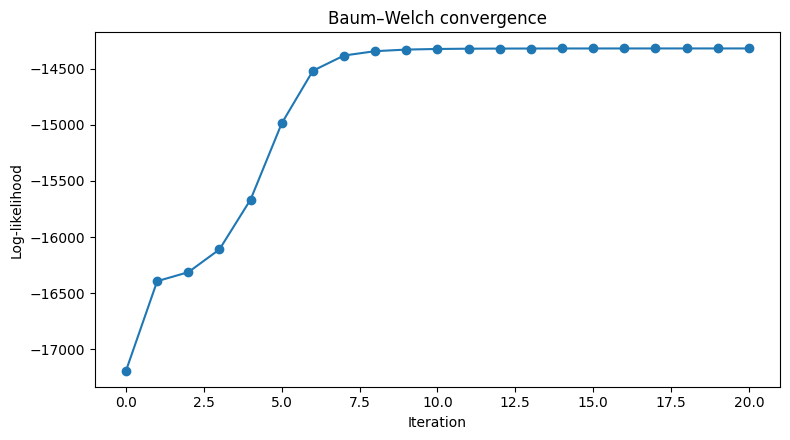

In [17]:

plt.figure(figsize=(8, 4.5))
plt.plot(np.arange(len(ll_history)), ll_history, marker="o")
plt.xlabel("Iteration")
plt.ylabel("Log-likelihood")
plt.title("Baum–Welch convergence")
plt.tight_layout()
plt.show()



## Cách đọc Baum–Welch convergence

Nếu implementation đúng, log-likelihood thường:

- tăng dần, hoặc
- gần như giữ nguyên khi hội tụ.

Điều này **không có nghĩa** ta đã tìm được global optimum.

EM phụ thuộc initialization và thường chỉ đảm bảo local optimum.


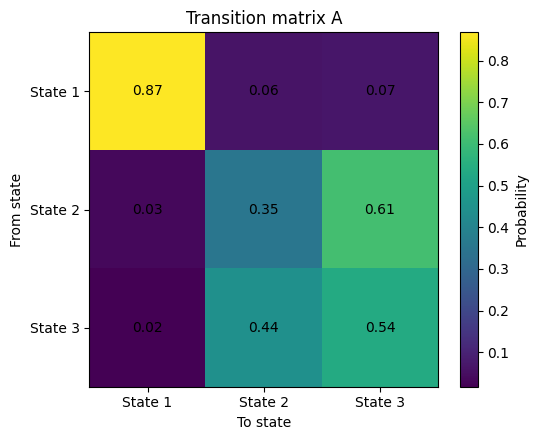

In [18]:

plt.figure(figsize=(5.5, 4.5))
plt.imshow(A, aspect="auto")
plt.xticks(range(N_STATES), [f"State {i+1}" for i in range(N_STATES)])
plt.yticks(range(N_STATES), [f"State {i+1}" for i in range(N_STATES)])
plt.xlabel("To state")
plt.ylabel("From state")
plt.title("Transition matrix A")
plt.colorbar(label="Probability")

for i in range(N_STATES):
    for j in range(N_STATES):
        plt.text(j, i, f"{A[i,j]:.2f}", ha="center", va="center")

plt.tight_layout()
plt.show()


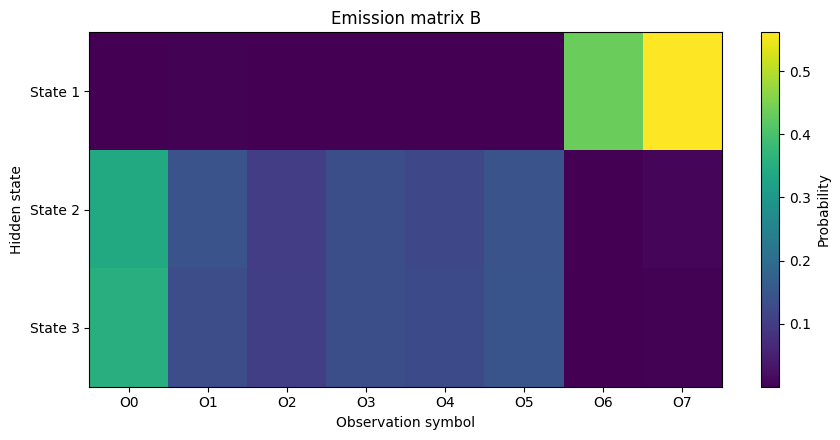

In [19]:

plt.figure(figsize=(9, 4.5))
plt.imshow(B, aspect="auto")
plt.xticks(range(N_SYMBOLS), [f"O{k}" for k in range(N_SYMBOLS)])
plt.yticks(range(N_STATES), [f"State {i+1}" for i in range(N_STATES)])
plt.xlabel("Observation symbol")
plt.ylabel("Hidden state")
plt.title("Emission matrix B")
plt.colorbar(label="Probability")
plt.tight_layout()
plt.show()


# 12. Decode hidden states bằng Viterbi

Sau khi có:

$$\Phi=(A,B,\pi)$$

ta tìm:

$$S^*=(s_1^*,s_2^*,\ldots,s_T^*)$$

là state sequence tốt nhất.

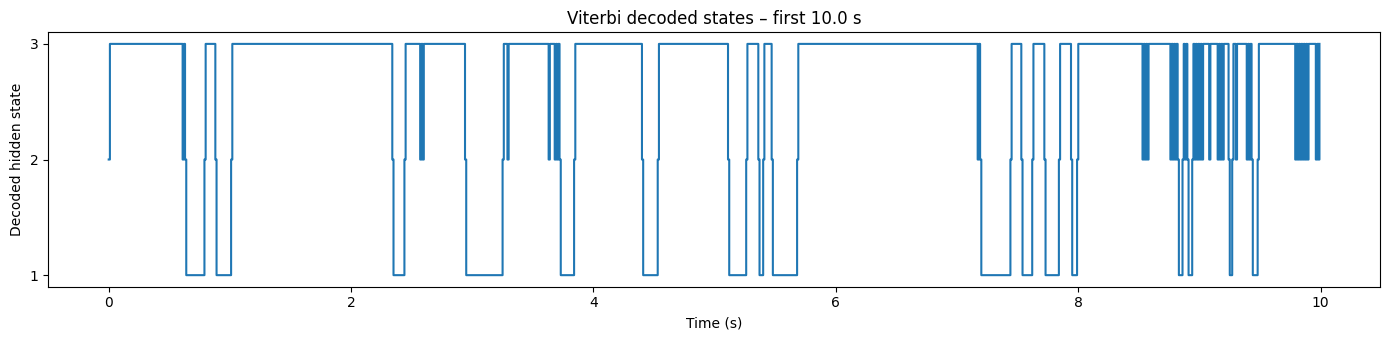

State 1: 15.69% frames
State 2: 9.91% frames
State 3: 74.40% frames


In [20]:

states, delta, psi = viterbi_decode(obs, A, B, pi)

plt.figure(figsize=(14, 3.5))
plt.step(
    frame_times[:view_n],
    states[:view_n] + 1,
    where="post",
)
plt.xlabel("Time (s)")
plt.ylabel("Decoded hidden state")
plt.yticks(range(1, N_STATES + 1))
plt.title(f"Viterbi decoded states – first {view_sec:.1f} s")
plt.tight_layout()
plt.show()

state_counts = np.bincount(states, minlength=N_STATES)
state_pct = 100 * state_counts / state_counts.sum()

for i, p in enumerate(state_pct):
    print(f"State {i+1}: {p:.2f}% frames")



## Cẩn thận khi diễn giải

Không được kết luận:

- State 1 = phoneme A,
- State 2 = phoneme B,
- State 3 = phoneme C,

chỉ dựa trên mô hình này.

Ta chưa cung cấp phoneme labels hay pronunciation model.

Viterbi chỉ trả lời:

> Trong HMM hiện tại, chuỗi hidden states nào giải thích observation sequence tốt nhất?


# 13. Forward trellis và Viterbi trellis

### Forward

$$\alpha_t(j) = \sum_i \alpha_{t-1}(i)a_{ij}b_j(X_t)$$

→ cộng tất cả path.

### Viterbi

$$\delta_t(j) = \max_i \delta_{t-1}(i)a_{ij}b_j(X_t)$$

→ giữ path tốt nhất.

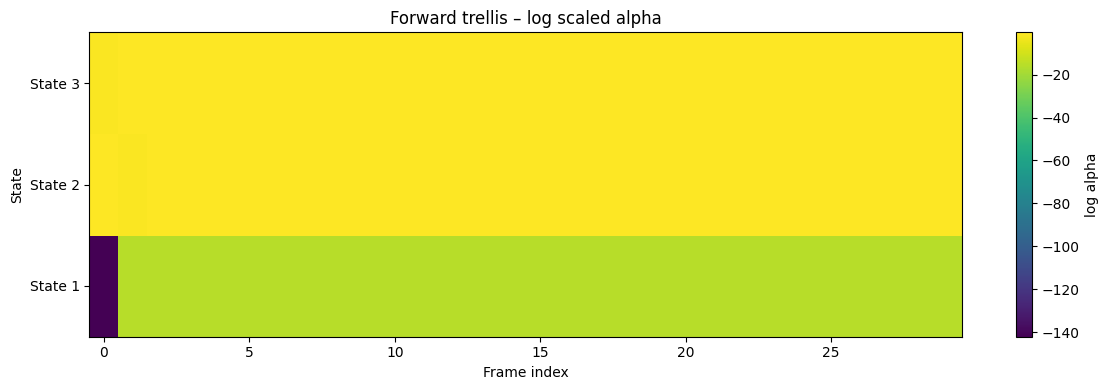

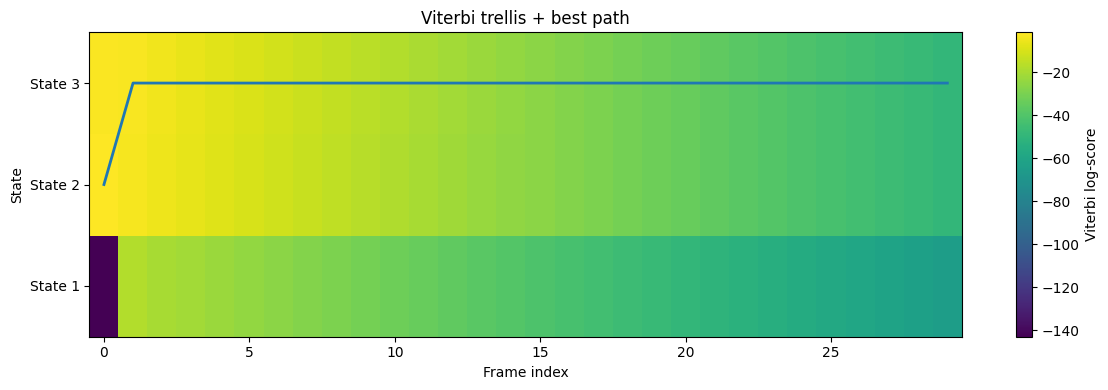

In [21]:

T_SMALL = 30
obs_small = obs[:T_SMALL]

alpha_small, scales_small, ll_small = forward_scaled(
    obs_small, A, B, pi
)

states_small, delta_small, psi_small = viterbi_decode(
    obs_small, A, B, pi
)

plt.figure(figsize=(12, 4))
plt.imshow(
    np.log(np.maximum(alpha_small, 1e-300)).T,
    origin="lower",
    aspect="auto",
)
plt.xlabel("Frame index")
plt.ylabel("State")
plt.yticks(range(N_STATES), [f"State {i+1}" for i in range(N_STATES)])
plt.title("Forward trellis – log scaled alpha")
plt.colorbar(label="log alpha")
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 4))
plt.imshow(
    delta_small.T,
    origin="lower",
    aspect="auto",
)
plt.plot(np.arange(T_SMALL), states_small, linewidth=2)
plt.xlabel("Frame index")
plt.ylabel("State")
plt.yticks(range(N_STATES), [f"State {i+1}" for i in range(N_STATES)])
plt.title("Viterbi trellis + best path")
plt.colorbar(label="Viterbi log-score")
plt.tight_layout()
plt.show()


# 14. 8.3 – Continuous HMM

Trong speech recognition thực tế, MFCC là vector liên tục.

Thay vì:

$$b_i(k)=P(o_k\mid s_t=i)$$

ta dùng mật độ:

$$b_j(x)$$

Một lựa chọn quan trọng trong HMM truyền thống là Gaussian mixture:

$$b_j(x) = \sum_{m=1}^{M} c_{jm} \mathcal{N}(x;\mu_{jm},\Sigma_{jm})$$

Trong đó:

- $c_{jm}$: mixture weight,
- $\mu_{jm}$: mean vector,
- $\Sigma_{jm}$: covariance matrix.

Phần code dưới dùng **1 Gaussian/state** và diagonal covariance để giữ việc học rõ ràng.

Đó vẫn là continuous HMM; GMM-HMM chỉ mở rộng mỗi state thành nhiều Gaussian.

In [22]:

def gaussian_diag_pdf(X, means, vars_, var_floor=1e-4):
    # X: [T, D], means/vars_: [N, D]
    vars_ = np.maximum(vars_, var_floor)

    diff = X[:, None, :] - means[None, :, :]

    log_det = np.sum(np.log(vars_), axis=1)[None, :]
    quad = np.sum(diff**2 / vars_[None, :, :], axis=2)

    D = X.shape[1]
    log_pdf = -0.5 * (
        D * np.log(2 * np.pi)
        + log_det
        + quad
    )

    return np.exp(np.maximum(log_pdf, -745.0))


def forward_scaled_cont(X, A, means, vars_, pi):
    E = gaussian_diag_pdf(X, means, vars_)
    T, N = E.shape

    alpha = np.zeros((T, N))
    scales = np.zeros(T)

    alpha[0] = pi * E[0]
    scales[0] = max(alpha[0].sum(), 1e-300)
    alpha[0] /= scales[0]

    for t in range(1, T):
        alpha[t] = (alpha[t-1] @ A) * E[t]
        scales[t] = max(alpha[t].sum(), 1e-300)
        alpha[t] /= scales[t]

    ll = np.log(scales).sum()
    return alpha, scales, ll, E


def backward_scaled_cont(E, A, scales):
    T, N = E.shape
    beta = np.zeros((T, N))
    beta[-1] = 1.0

    for t in range(T-2, -1, -1):
        beta[t] = A @ (E[t+1] * beta[t+1])
        beta[t] /= max(scales[t+1], 1e-300)

    return beta


In [23]:

def baum_welch_gaussian_diag(
    X,
    n_states=3,
    n_iter=10,
    seed=42,
    var_floor=1e-3,
):
    km = KMeans(
        n_clusters=n_states,
        random_state=seed,
        n_init=10,
    ).fit(X)

    means = km.cluster_centers_.copy()

    global_var = np.var(X, axis=0) + var_floor
    vars_ = np.tile(global_var, (n_states, 1))

    for j in range(n_states):
        cluster = X[km.labels_ == j]
        if len(cluster) > 1:
            vars_[j] = np.var(cluster, axis=0) + var_floor

    A = normalize_rows(
        np.full((n_states, n_states), 0.1)
        + np.eye(n_states) * 0.7
    )

    pi = np.full(n_states, 1.0 / n_states)
    history = []

    for _ in range(n_iter):
        alpha, scales, ll, E = forward_scaled_cont(
            X, A, means, vars_, pi
        )

        beta = backward_scaled_cont(E, A, scales)
        history.append(ll)

        gamma = alpha * beta
        gamma /= np.maximum(
            gamma.sum(axis=1, keepdims=True),
            1e-300,
        )

        xi_sum = np.zeros_like(A)

        for t in range(len(X) - 1):
            numer = (
                alpha[t, :, None]
                * A
                * (E[t+1] * beta[t+1])[None, :]
            )
            xi_sum += numer / max(numer.sum(), 1e-300)

        pi = gamma[0].copy()

        A = xi_sum / np.maximum(
            gamma[:-1].sum(axis=0)[:, None],
            1e-12,
        )
        A = normalize_rows(A)

        gamma_sum = np.maximum(gamma.sum(axis=0), 1e-12)
        means = (gamma.T @ X) / gamma_sum[:, None]

        for j in range(n_states):
            diff = X - means[j]
            vars_[j] = (
                gamma[:, j, None] * diff**2
            ).sum(axis=0) / gamma_sum[j]

        vars_ = np.maximum(vars_, var_floor)

    _, _, final_ll, _ = forward_scaled_cont(
        X, A, means, vars_, pi
    )
    history.append(final_ll)

    return A, means, vars_, pi, np.array(history)


## Train Continuous Gaussian HMM

Ta train trực tiếp trên normalized MFCC:

$$X_t \in \mathbb{R}^{13}$$

Không cần Vector Quantization.

Continuous HMM pi:
[0. 0. 1.]

Continuous HMM A:
[[0.9288 0.0596 0.0116]
 [0.0838 0.9162 0.    ]
 [0.0389 0.     0.9611]]


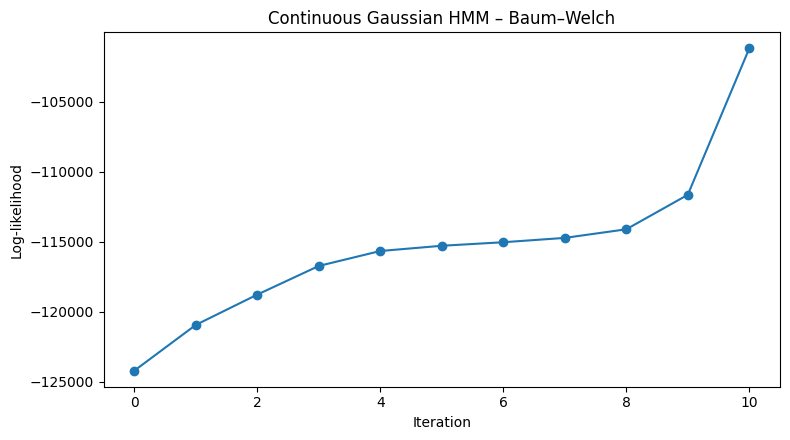

In [24]:

A_c, means_c, vars_c, pi_c, ll_cont = baum_welch_gaussian_diag(
    mfcc_norm,
    n_states=3,
    n_iter=10,
)

print("Continuous HMM pi:")
print(pi_c)

print("\nContinuous HMM A:")
print(A_c)

plt.figure(figsize=(8, 4.5))
plt.plot(np.arange(len(ll_cont)), ll_cont, marker="o")
plt.xlabel("Iteration")
plt.ylabel("Log-likelihood")
plt.title("Continuous Gaussian HMM – Baum–Welch")
plt.tight_layout()
plt.show()


# 15. 8.3.2 – Semi-continuous / Tied-mixture HMM

Semi-continuous HMM đứng giữa discrete HMM và continuous mixture HMM.

Ý tưởng:

- có một **shared codebook** các density,
- các state dùng chung Gaussian kernels,
- mỗi state có **mixture weights riêng**.

$$b_j(x) = \sum_k b_j(k)f(x\mid o_k)$$

Có thể hình dung:

- **Discrete HMM**: observation gần như được gán vào một codeword.
- **Semi-continuous HMM**: nhiều shared kernels cùng đóng góp.
- **Continuous mixture HMM**: mỗi state có mixture density riêng.

Phần Vector Quantization ở trên giúp thấy trực quan cây cầu từ continuous feature sang discrete representation.


# 16. 8.4 – Practical Issues in Using HMMs

## 8.4.1. Initial Estimates

Baum–Welch chỉ đảm bảo local optimum.

Với discrete HMM:

- có thể bắt đầu gần uniform,
- tránh xác suất bằng 0 nếu không muốn nó bị giữ bằng 0 mãi.

Với continuous HMM:

- mean/covariance nên khởi tạo hợp lý,
- K-Means là một lựa chọn thực tế.

Trong notebook:

- discrete HMM: random + normalize,
- continuous HMM: K-Means cho Gaussian means.


## 8.4.2. Model Topology

Speech là tín hiệu biến đổi theo thời gian.

Topology thường gặp cho phone/word HMM là **left-to-right**:

$$1\rightarrow1,\quad 1\rightarrow2,\quad 2\rightarrow2,\quad 2\rightarrow3,\ldots$$

Self-loop $a_{ii}$ cho phép state tồn tại nhiều frame.

Transition $a_{i,i+1}$ mô hình hóa tiến trình theo thời gian.

Trong demo này ta train một HMM trên cả recording dài, không có label, nên dùng topology linh hoạt hơn. Với phone/word model riêng, left-to-right thường tự nhiên hơn.

Ví dụ left-to-right topology:
[[0.7 0.3 0. ]
 [0.  0.7 0.3]
 [0.  0.  1. ]]


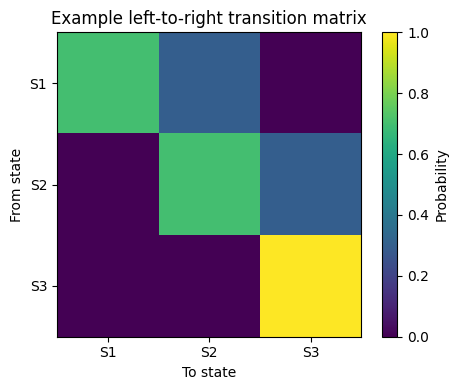

In [25]:

A_left_to_right = np.array([
    [0.7, 0.3, 0.0],
    [0.0, 0.7, 0.3],
    [0.0, 0.0, 1.0],
])

print("Ví dụ left-to-right topology:")
print(A_left_to_right)

plt.figure(figsize=(5, 4))
plt.imshow(A_left_to_right)
plt.xticks(range(3), ["S1", "S2", "S3"])
plt.yticks(range(3), ["S1", "S2", "S3"])
plt.xlabel("To state")
plt.ylabel("From state")
plt.title("Example left-to-right transition matrix")
plt.colorbar(label="Probability")
plt.tight_layout()
plt.show()


## 8.4.3. Training Criteria

Baum–Welch ở trên dùng **Maximum Likelihood**:

$$\max_\Phi P(X\mid\Phi)$$

MLE rất quan trọng và đơn giản, nhưng HMM chỉ là xấp xỉ cho speech.

Vì các giả định của HMM không hoàn toàn đúng với speech thật, những tiêu chí discriminative khác có thể được dùng trong các hệ thống khác.

Notebook này tập trung vào MLE vì đó là nền tảng để hiểu Baum–Welch.


## 8.4.4–8.4.5. Deleted Interpolation và Parameter Smoothing

Khi dữ liệu ít:

- transition/emission có thể được ước lượng kém,
- xác suất có thể về 0,
- covariance có thể không ổn định.

Hướng xử lý:

- thêm dữ liệu,
- giảm số tham số,
- interpolation với model tổng quát hơn,
- probability flooring,
- parameter tying,
- diagonal covariance.

Trong code discrete HMM ta đã dùng một flooring rất nhẹ:

```python
B = normalize_rows(B_new + 1e-10)
```


## 8.4.6. Probability Representation và Underflow

Với chuỗi dài:

$$P(X\mid\Phi)$$

là tích của rất nhiều số nhỏ hơn 1.

Ví dụ:

$$0.01^{1000}$$

gần như bằng 0 trong floating-point.

Hai cách xử lý chính:

### Scaling

Scale $\alpha_t$ và $\beta_t$ ở mỗi time step.

Notebook Forward/Backward đang dùng cách này.

### Log domain

$$\log(ab)=\log a+\log b$$

Viterbi trong notebook dùng log domain.

# 17. 8.5 – HMM Limitations

## 8.5.1. Duration Modeling

Với self-loop probability $a_{ii}$, thời gian ở state có dạng geometric/exponential:

$$P(D=d)\propto a_{ii}^{d-1}(1-a_{ii})$$

Duration thật của phoneme không nhất thiết theo dạng này.

Một hướng khắc phục là **explicit duration HMM**.

## 8.5.2. First-order Assumption

HMM bậc 1 giả định:

$$P(s_t\mid s_{t-1},s_{t-2},\ldots) = P(s_t\mid s_{t-1})$$

Trong speech, trạng thái hiện tại có thể chịu ảnh hưởng dài hơn.

Có thể mở rộng thành second-order HMM, nhưng:

- state space tăng,
- số tham số tăng,
- computation tăng mạnh.

## 8.5.3. Conditional Independence Assumption

HMM chuẩn giả định:

$$P(X_t\mid X_{1:t-1},s_t) = P(X_t\mid s_t)$$

Nhưng các frame speech lân cận thường tương quan mạnh.

Ví dụ:

- formant thay đổi liên tục,
- energy thay đổi liên tục,
- MFCC ở frame $t$ và $t+1$ không thật sự độc lập.

Đây là một giới hạn quan trọng của HMM truyền thống.

# 18. Tổng kết toàn pipeline

$$\boxed{\text{Audio}} \rightarrow \boxed{\text{Frames}} \rightarrow \boxed{\text{MFCC}}$$

Sau đó có hai hướng:

### Discrete HMM

$$\text{MFCC} \rightarrow \text{Vector Quantization} \rightarrow O_1,\ldots,O_T \rightarrow \text{Discrete HMM}$$

### Continuous HMM

$$\text{MFCC vectors} \rightarrow \text{Gaussian emission densities} \rightarrow \text{Continuous HMM}$$

Ba bài toán:

$$\boxed{\text{Forward}\rightarrow P(X\mid\Phi)}$$

$$\boxed{\text{Viterbi}\rightarrow S^*}$$

$$\boxed{\text{Baum–Welch}\rightarrow \hat{\Phi}}$$

# 19. Bài tập tự luyện

### Bài 1 – Markov Chain

Cho:

$$\pi=[0.8,0.2]$$

$$A=\begin{bmatrix} 0.7&0.3\\ 0.4&0.6 \end{bmatrix}$$

Tính bằng tay:

$$P(S_1=1,S_2=1,S_3=2)$$

### Bài 2 – Forward

Lấy 3 state và 3 observation đầu tiên.  
Tự tính $\alpha_1,\alpha_2,\alpha_3$, rồi đối chiếu code.

### Bài 3 – Viterbi

Với cùng 3 observation:

- tính $\delta_t(j)$,
- lưu $\psi_t(j)$,
- backtrack state sequence.

### Bài 4 – Baum–Welch

Quan sát `ll_history` và giải thích vì sao likelihood tăng dần.

### Bài 5 – Topology

Thay ergodic transition matrix bằng left-to-right topology.  
So sánh likelihood và state path.

### Bài 6 – Số hidden states

Thử 2, 3, 5 states và so sánh cách phân đoạn.

### Bài 7 – Discrete vs Continuous HMM

Giải thích trade-off giữa:

- quantization error,
- số tham số,
- complexity,
- lượng training data.


# 20. Checklist kiến thức cần nhớ

Sau notebook này, bạn nên trả lời được:

- Markov assumption là gì?
- HMM khác Markov chain ở đâu?
- \(A,B,\pi\) nghĩa là gì?
- Hidden state và observation khác nhau thế nào?
- Vì sao speech phải chia frame?
- MFCC đóng vai trò gì?
- Forward tính cái gì?
- Viterbi khác Forward ở đâu?
- Baum–Welch là EM như thế nào?
- \(\alpha,\beta,\gamma,\xi\) nghĩa là gì?
- Vì sao cần scaling/log domain?
- Left-to-right HMM phù hợp với speech ở điểm nào?
- Discrete, continuous và semi-continuous HMM khác nhau ra sao?
- Ba hạn chế lớn của HMM chuẩn là gì?

Nếu trả lời được các câu trên và tự code được 3 thuật toán cốt lõi, bạn đã nắm rất chắc phần nền tảng của Chương 8.


# Chương 11 – Language Modeling

Trong chương này, chúng ta sẽ xây dựng và thực hành các khái niệm cốt lõi của Mô hình ngôn ngữ (Language Modeling):
1. **N-gram Models** (Unigram, Bigram, Trigram)
2. **Perplexity** (Độ hỗn loạn - dùng để đánh giá mô hình)
3. **Smoothing Techniques** (Kỹ thuật làm mịn/làm mềm tránh xác suất bằng 0):
   - Laplace (Add-one) & Add-k
   - Backoff / Interpolation cơ bản
   - Deleted Interpolation
4. **Class N-grams** (Mô hình ngôn ngữ dựa trên phân lớp từ)

## 11.1. N-gram Models (Mô hình N-gram)

Mô hình ngôn ngữ tính xác suất của một chuỗi từ $W = (w_1, w_2, \dots, w_T)$:

$$P(W) = \prod_{i=1}^{T} P(w_i \mid w_1, \dots, w_{i-1})$$

Với giả thiết Markov bậc $N-1$:

- **Unigram (N=1):** $P(w_i)$
- **Bigram (N=2):** $P(w_i \mid w_{i-1}) = \frac{C(w_{i-1}, w_i)}{C(w_{i-1})}$
- **Trigram (N=3):** $P(w_i \mid w_{i-2}, w_{i-1}) = \frac{C(w_{i-2}, w_{i-1}, w_i)}{C(w_{i-2}, w_{i-1})}$

Dưới đây ta sẽ chuẩn bị một tập dữ liệu nhỏ (corpus) bằng tiếng Việt để huấn luyện mô hình.

In [26]:
import math
from collections import Counter, defaultdict

# Corpus mẫu
corpus = [
    "tôi thích học xử lý tín hiệu âm thanh",
    "học máy và xử lý ngôn ngữ tự nhiên",
    "tôi thích học mô hình ngôn ngữ học",
    "xử lý tín hiệu và nhận dạng tiếng nói"
]

def tokenize(text):
    # Thêm ký hiệu bắt đầu <s> và kết thúc </s> câu
    return ["<s>"] + text.lower().split() + ["</s>"]

tokenized_corpus = [tokenize(sentence) for sentence in corpus]
print("Ví dụ câu sau khi tokenize:", tokenized_corpus[0])

Ví dụ câu sau khi tokenize: ['<s>', 'tôi', 'thích', 'học', 'xử', 'lý', 'tín', 'hiệu', 'âm', 'thanh', '</s>']


### Xây dựng hàm đếm tần suất n-gram

In [27]:
def get_ngrams(tokens, n):
    return [tuple(tokens[i:i+n]) for i in range(len(tokens) - n + 1)]

# Đếm tần suất các n-gram xuất hiện trong toàn bộ corpus
unigram_counts = Counter()
bigram_counts = Counter()
trigram_counts = Counter()

for tokens in tokenized_corpus:
    unigram_counts.update(get_ngrams(tokens, 1))
    bigram_counts.update(get_ngrams(tokens, 2))
    trigram_counts.update(get_ngrams(tokens, 3))

print("Top 5 Unigram phổ biến nhất:", unigram_counts.most_common(5))
print("Top 5 Bigram phổ biến nhất:", bigram_counts.most_common(5))

Top 5 Unigram phổ biến nhất: [(('<s>',), 4), (('học',), 4), (('</s>',), 4), (('xử',), 3), (('lý',), 3)]
Top 5 Bigram phổ biến nhất: [(('xử', 'lý'), 3), (('<s>', 'tôi'), 2), (('tôi', 'thích'), 2), (('thích', 'học'), 2), (('lý', 'tín'), 2)]


## 11.2. Perplexity (Độ hỗn loạn)

Perplexity ($PP$) là độ đo chất lượng của mô hình ngôn ngữ. Giá trị $PP$ càng thấp chứng tỏ mô hình càng tốt (ít bị bất ngờ trước dữ liệu mới).

$$PP(W) = P(w_1, w_2, \dots, w_T)^{-\frac{1}{T}} = 2^{-\frac{1}{T} \sum_{i=1}^T \log_2 P(w_i \mid w_{1:i-1})}$$

Chúng ta sẽ viết hàm tính Perplexity dựa trên mô hình Bigram.

In [28]:
def calculate_perplexity(test_sentence, bigram_probs, vocab_size):
    tokens = tokenize(test_sentence)
    bigrams = get_ngrams(tokens, 2)

    log_prob_sum = 0
    N = len(tokens) - 1 # Không tính từ khởi đầu <s> làm bia đích dự đoán

    for bg in bigrams:
        prob = bigram_probs.get(bg, 1e-12) # Tránh log(0)
        log_prob_sum += math.log2(prob)

    entropy = - (log_prob_sum / N)
    perplexity = 2 ** entropy
    return perplexity

print("Hàm tính Perplexity đã sẵn sàng.")

Hàm tính Perplexity đã sẵn sàng.


## 11.3. Smoothing (Các kỹ thuật làm mịn)

Nếu một n-gram chưa từng xuất hiện trong tập huấn luyện, xác suất của nó bằng $0$, dẫn tới Perplexity tiến tới vô cùng. Smoothing giải quyết vấn đề này.

### 11.3.1. Laplace (Add-one) & Add-k Smoothing

$$P_{\text{Laplace}}(w_i \mid w_{i-1}) = \frac{C(w_{i-1}, w_i) + 1}{C(w_{i-1}) + V}$$

Với $V$ là kích thước từ vựng (Vocabulary size).

In [29]:
# Tạo từ vựng (Vocabulary)
vocab = set([word[0] for word in unigram_counts.keys()])
V = len(vocab)
print("Vocabulary size (V) =", V)

# Tính xác suất Bigram áp dụng Laplace Smoothing
bigram_probs_laplace = {}
for bg, count in bigram_counts.items():
    context = (bg[0],)
    context_count = unigram_counts[context]
    bigram_probs_laplace[bg] = (count + 1) / (context_count + V)

# Thêm xác suất cho các cặp từ chưa từng gặp
for w1 in vocab:
    for w2 in vocab:
        bg = (w1, w2)
        if bg not in bigram_probs_laplace:
            context_count = unigram_counts.get((w1,), 0)
            bigram_probs_laplace[bg] = 1 / (context_count + V)

test_sentence = "tôi thích xử lý tín hiệu"
pp = calculate_perplexity(test_sentence, bigram_probs_laplace, V)
print(f"Perplexity của câu '{test_sentence}' với Laplace Smoothing: {pp:.3f}")

Vocabulary size (V) = 23
Perplexity của câu 'tôi thích xử lý tín hiệu' với Laplace Smoothing: 11.193


### 11.3.2. Deleted Interpolation (Nội suy tuyến tính giảm thiểu)

Phương pháp này kết hợp các mô hình Unigram, Bigram và Trigram bằng cách tính trung bình có trọng số:

$$P_{\text{interp}}(w_i \mid w_{i-2}, w_{i-1}) = \lambda_1 P(w_i \mid w_{i-2}, w_{i-1}) + \lambda_2 P(w_i \mid w_{i-1}) + \lambda_3 P(w_i)$$

Với $\lambda_1 + \lambda_2 + \lambda_3 = 1$.

Trong kỹ thuật **Deleted Interpolation**, ta tự động hóa việc tìm các tham số $\lambda$ bằng cách loại bỏ bớt (deleting) một số n-gram khỏi tập train rồi kiểm tra trên phần còn lại.

In [30]:
def deleted_interpolation_weights(trigram_counts, bigram_counts, unigram_counts, total_words):
    """
    Ước lượng lambda_1, lambda_2, lambda_3 bằng thuật toán Deleted Interpolation đơn giản hóa
    """
    l1 = l2 = l3 = 0.0

    for trigram, count in trigram_counts.items():
        if count > 0:
            w1, w2, w3 = trigram

            # Tính điểm số cho từng cấp n-gram
            denom_tri = bigram_counts.get((w1, w2), 0)
            val_tri = (count - 1) / (denom_tri - 1) if denom_tri > 1 else 0

            denom_bi = unigram_counts.get((w2,), 0)
            val_bi = (bigram_counts.get((w2, w3), 0) - 1) / (denom_bi - 1) if denom_bi > 1 else 0

            val_uni = (unigram_counts.get((w3,), 0) - 1) / (total_words - 1) if total_words > 1 else 0

            max_val = max(val_tri, val_bi, val_uni)
            if max_val == val_tri:
                l1 += count
            elif max_val == val_bi:
                l2 += count
            else:
                l3 += count

    # Chuẩn hóa tổng lambda = 1
    total_l = l1 + l2 + l3
    if total_l > 0:
        l1 /= total_l
        l2 /= total_l
        l3 /= total_l
    else:
        l1, l2, l3 = 0.33, 0.33, 0.34

    return l1, l2, l3

total_words = sum(unigram_counts.values())
l1, l2, l3 = deleted_interpolation_weights(trigram_counts, bigram_counts, unigram_counts, total_words)
print(f"Bộ trọng số tối ưu học được: lambda_1 (Trigram) = {l1:.4f}, lambda_2 (Bigram) = {l2:.4f}, lambda_3 (Unigram) = {l3:.4f}")

Bộ trọng số tối ưu học được: lambda_1 (Trigram) = 0.5429, lambda_2 (Bigram) = 0.1429, lambda_3 (Unigram) = 0.3143


## 11.4. Class N-grams (Mô hình N-gram phân lớp)

Khi dữ liệu huấn luyện mỏng, nhiều từ có cùng đặc tính ngữ nghĩa/ngữ pháp (ví dụ: các loại quả, tên thành phố) có thể được gom vào một **Class (C)**.

$$P(w_i \mid w_{i-1}) \approx P(w_i \mid C_i) \times P(C_i \mid C_{i-1})$$

Điều này làm giảm số lượng tham số cần ước lượng từ $O(V^2)$ xuống $O(C^2 + V)$.

In [31]:
# Giả định một Class Map đơn giản cho hai thực thể ngôn ngữ:
# Từ "học", "nhận dạng" thuộc Class: HOẠT_ĐỘNG
# Từ "tín hiệu", "ngôn ngữ", "tiếng nói" thuộc Class: ĐỐI_TƯỢNG

word_to_class = {
    "học": "CLASS_ACT",
    "nhận dạng": "CLASS_ACT",
    "tín hiệu": "CLASS_OBJ",
    "ngôn ngữ": "CLASS_OBJ",
    "tiếng nói": "CLASS_OBJ"
}

def get_class(word):
    return word_to_class.get(word, word.upper())

# Biến đổi corpus gốc thành class corpus
class_corpus = [[get_class(w) for w in tokens] for tokens in tokenized_corpus]
print("Nguyên bản:", tokenized_corpus[1])
print("Dạng Class:", class_corpus[1])

Nguyên bản: ['<s>', 'học', 'máy', 'và', 'xử', 'lý', 'ngôn', 'ngữ', 'tự', 'nhiên', '</s>']
Dạng Class: ['<S>', 'CLASS_ACT', 'MÁY', 'VÀ', 'XỬ', 'LÝ', 'NGÔN', 'NGỮ', 'TỰ', 'NHIÊN', '</S>']


### Bài tập tự luyện Chương 11:
1. **Bài tập 1**: Dùng tập dữ liệu tiếng Việt nhỏ phía trên để tự tính xác suất của chuỗi từ: `"tôi thích học ngôn ngữ"` dùng mô hình Bigram có áp dụng Laplace Smoothing.
2. **Bài tập 2**: Giải thích chi tiết tại sao Perplexity ($PP$) lại tỷ lệ nghịch với độ chính xác và khả năng dự đoán của mô hình ngôn ngữ.